# Multimodal AutoML LOOCV — MSN × FC (cortical 68 매칭) + Structure–Function Coupling

MSN(형태 유사도)과 FC(기능 연결)를 **같은 DK cortical 68 ROI**로 맞춰서 결합한다.
뼈대(6개 모델 · LOOCV · nested GridSearchCV · fold 안에서 residualize → PCA)는
`../automl_comparison_paired_multimodal_morphPCA_FCtop2.ipynb`와 동일하다.

## 데이터 (루트의 CSV를 `../`로 읽음)

| 파일 | 내용 | 만든 곳 |
|---|---|---|
| `msn_strength_68.csv` | MSN regional MS 68개 | `build_msn_dataset.py` |
| `fc_strength_68.csv` | FC strength 68개 (피질 67개 파트너 평균) | `build_fc_dataset.py` |
| `msn_full_68x68.csv`, `fc_full_68x68.csv` | edge 2278개씩 → coupling 계산에만 사용 | 같음 |

## 표본
MSN 45명 ∩ FC 44명 = **공통 44명** (sub-001은 FC 없음). 타겟 `vas_t1`, 임상 `vas_t0` + `treatment_group`.

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | 뇌 피처 | nuisance (fold 안 train에서만 fit) |
|---|---|---|
| `Clinical_ONLY` | 없음 | — |
| `MSN_PCA3` | MSN strength 68 → PCA 3 | age, sex, eTIV |
| `FC68_PCA3` | FC strength 68 → PCA 3 | age, sex, mean_fd |
| `Multimodal` | MSN PCA3 + FC68 PCA3 | 모달리티별로 따로 |
| `Coupling_PCA3` | ROI별 MSN–FC coupling 68 → PCA 3 | age, sex, eTIV, mean_fd |

PCA 성분 수 3은 기존 멀티모달 노트북과 맞춘 **사전 고정값**이다. 결과를 보고 바꾸지 않는다.

## Coupling이란
피험자마다, ROI i마다:
- MSN 행렬의 i행 = ROI i가 나머지 67개 ROI와 **얼마나 닮았나** (형태)
- FC 행렬의 i행 = ROI i가 같은 67개 ROI와 **얼마나 같이 움직이나** (기능)
- 이 67쌍의 Pearson r = **ROI i의 구조–기능 결합도**

두 행렬의 ROI가 순서까지 같아야 i행끼리 짝을 지을 수 있다. 이것이 68×68 매칭이 필요한 이유다.
vas를 쓰지 않고 피험자 안에서만 계산하므로 CV 밖에서 미리 계산해도 leakage가 없다.


In [1]:
import os
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피.
# LOCALAPPDATA는 사용자 이름(한글)이 들어가 있어 안 되므로 ASCII 경로를 직접 쓴다 (FC 노트북과 동일).
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (MSN 68 + FC 68, rid 기준 결합)
# ==========================================================
DATA_DIR = '..'   # 데이터 CSV는 TMS 루트에 있다

def load(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name), skipinitialspace=True)
    d.columns = d.columns.str.strip()
    return d

msn_s = load('msn_strength_68.csv')   # 앞 7열: rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV
fc_s  = load('fc_strength_68.csv')    # 앞 7열: ... mean_fd
msn_e = load('msn_full_68x68.csv')
fc_e  = load('fc_full_68x68.csv')

# --- ROI 매칭 확인: 접미사만 떼면 이름과 순서가 같아야 한다 ---
ROIS = [c[:-len('_msn')] for c in msn_s.columns[7:]]
assert len(ROIS) == 68, len(ROIS)
assert [c[:-len('_fc')] for c in fc_s.columns[7:]] == ROIS, 'strength ROI 순서 불일치'
msn_edge_cols, fc_edge_cols = list(msn_e.columns[7:]), list(fc_e.columns[7:])
assert [c[:-len('_msn')] for c in msn_edge_cols] == fc_edge_cols, 'edge 순서 불일치'

# --- 임상 변수는 두 파일 모두 structural CSV에서 왔으므로 공통 44명에서 같아야 한다 ---
chk = msn_s.merge(fc_s, on='rid', suffixes=('_m', '_f'))
for c in ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex']:
    assert np.allclose(chk[f'{c}_m'], chk[f'{c}_f']), c

# --- rid inner join: 공통 44명 ---
df = (msn_s.merge(fc_s[['rid', 'mean_fd'] + list(fc_s.columns[7:])], on='rid', how='inner')
      .sort_values('rid').reset_index(drop=True))
assert len(df) == 44, len(df)

# edge 표도 df와 같은 rid 순서로 맞춘다
E_msn = msn_e.set_index('rid').loc[df['rid'], msn_edge_cols].values   # (44, 2278)
E_fc  = fc_e.set_index('rid').loc[df['rid'], fc_edge_cols].values     # (44, 2278)

# ---- ROI별 structure–function coupling (44 x 68) ----
IU = np.triu_indices(68, k=1)
OFF = ~np.eye(68, dtype=bool)

def to_matrix(edge_row):
    M = np.zeros((68, 68))
    M[IU] = edge_row
    return M + M.T          # 대각은 OFF로 빼고 쓰므로 0으로 둔다

def coupling(msn_edges, fc_edges):
    """ROI i: MSN i행과 FC i행(자기 자신 제외 67개)의 Pearson r."""
    S, F = to_matrix(msn_edges), to_matrix(fc_edges)
    return np.array([np.corrcoef(S[i, OFF[i]], F[i, OFF[i]])[0, 1] for i in range(68)])

X_coup = np.array([coupling(E_msn[k], E_fc[k]) for k in range(len(df))])
assert np.all(np.isfinite(X_coup))

X_msn      = df[[f'{r}_msn' for r in ROIS]].values
X_fc       = df[[f'{r}_fc' for r in ROIS]].values
X_nuis_msn = df[['age', 'sex', 'eTIV']].values
X_nuis_fc  = df[['age', 'sex', 'mean_fd']].values
X_nuis_cp  = df[['age', 'sex', 'eTIV', 'mean_fd']].values   # coupling은 두 모달리티의 교란을 다 받는다
X_clinical = df[['vas_t0', 'treatment_group']].values
y          = df['vas_t1'].values
group      = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

print(f'n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'MSN strength {X_msn.shape[1]} | FC strength {X_fc.shape[1]} | coupling {X_coup.shape[1]}')
print(f'coupling 전체 평균 {X_coup.mean():+.3f} (SD {X_coup.std():.3f}) | '
      f'피험자별 전뇌 평균 {X_coup.mean(1).min():+.3f} ~ {X_coup.mean(1).max():+.3f}')

n = 44  |  Active 25 / Sham 19
MSN strength 68 | FC strength 68 | coupling 68
coupling 전체 평균 +0.202 (SD 0.217) | 피험자별 전뇌 평균 +0.103 ~ +0.308


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA = 3   # 세 모달리티 모두 사전 고정 (기존 멀티모달 노트북과 동일)

DATA_TYPES = ['Clinical_ONLY', 'MSN_PCA3', 'FC68_PCA3', 'Multimodal', 'Coupling_PCA3']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 모달리티별 nuisance residualization → scale → PCA → stack → StandardScaler
#    ※ 5 datasets x 6 models x 44 folds — 수 분 ~ 수십 분 소요
# ==========================================================
def resid_pca(X, N, tr, te):
    """nuisance 회귀 잔차 → 표준화 → PCA(N_PCA). 전부 train에서만 fit."""
    reg = LinearRegression().fit(N[tr], X[tr])
    X_tr = X[tr] - reg.predict(N[tr])
    X_te = X[te] - reg.predict(N[te])
    sc = StandardScaler().fit(X_tr)
    pca = PCA(n_components=N_PCA, random_state=42).fit(sc.transform(X_tr))
    return (pca.transform(sc.transform(X_tr)), pca.transform(sc.transform(X_te)),
            pca.explained_variance_ratio_.sum())

loo = LeaveOneOut()
predictions     = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
evr_log = {'MSN': [], 'FC68': [], 'Coupling': []}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_msn)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr = y[tr]
    y_true.append(y[te][0])

    Xs_tr, Xs_te, ev_s = resid_pca(X_msn,  X_nuis_msn, tr, te)
    Xf_tr, Xf_te, ev_f = resid_pca(X_fc,   X_nuis_fc,  tr, te)
    Xp_tr, Xp_te, ev_p = resid_pca(X_coup, X_nuis_cp,  tr, te)
    evr_log['MSN'].append(ev_s)
    evr_log['FC68'].append(ev_f)
    evr_log['Coupling'].append(ev_p)

    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]

    feat_sets = {
        'Clinical_ONLY': (Xc_tr, Xc_te),
        'MSN_PCA3':      (np.hstack([Xs_tr, Xc_tr]),        np.hstack([Xs_te, Xc_te])),
        'FC68_PCA3':     (np.hstack([Xf_tr, Xc_tr]),        np.hstack([Xf_te, Xc_te])),
        'Multimodal':    (np.hstack([Xs_tr, Xf_tr, Xc_tr]), np.hstack([Xs_te, Xf_te, Xc_te])),
        'Coupling_PCA3': (np.hstack([Xp_tr, Xc_tr]),        np.hstack([Xp_te, Xc_te])),
    }

    for dt in DATA_TYPES:
        Xtr_raw, Xte_raw = feat_sets[dt]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        for name, model in models.items():
            gcv = GridSearchCV(model, param_grids[name], cv=3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
            gcv.fit(Xtr, y_tr)
            predictions[(dt, name)].append(float(gcv.best_estimator_.predict(Xte)[0]))
            best_params_log[(dt, name)].append(str(gcv.best_params_))

y_true = np.array(y_true)
print("\n\nLOOCV done.")
print('PCA3 누적 설명분산 평균: ' +
      '  |  '.join(f'{k} {np.mean(v):.1%}' for k, v in evr_log.items()))

Starting LOOCV: 6 models x 5 datasets x 44 folds ...

fold 44/44

LOOCV done.
PCA3 누적 설명분산 평균: MSN 67.3%  |  FC68 79.7%  |  Coupling 40.7%


In [5]:
# ==========================================================
# 4. EVALUATION  (overall + Active/Sham)
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

rows = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in [('Overall', np.ones(len(y_true), bool)),
                     ('Active', group == 'Active'),
                     ('Sham',   group == 'Sham')]:
        rows.append({'Data Type': dt, 'Model': name, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res = pd.DataFrame(rows)

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음\n")

# --- overall RMSE 표: 행 = 모델, 열 = 피처셋 / d = 양수면 오른쪽(뒤) 조건이 이득 ---
ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
D_COLS = {
    'd_Multi_vs_MSN':   ('MSN_PCA3',      'Multimodal'),
    'd_Multi_vs_FC68':  ('FC68_PCA3',     'Multimodal'),
    'd_Coup_vs_Clin':   ('Clinical_ONLY', 'Coupling_PCA3'),
    'd_Multi_vs_Clin':  ('Clinical_ONLY', 'Multimodal'),
}
for col, (a, b) in D_COLS.items():
    ov[col] = ov[a] - ov[b]

print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========")
for col in D_COLS:
    n_pos = int((ov[col] > 0).sum())
    lin = int((ov.loc[['LinearRegression', 'ElasticNet', 'SVR_Linear', 'SVR_RBF'], col] > 0).sum())
    print(f"  {col:17s} {n_pos}/6   (선형·커널 4개 중 {lin})")
print("  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음

========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_PCA3,d_Multi_vs_MSN,d_Multi_vs_FC68,d_Coup_vs_Clin,d_Multi_vs_Clin
Model,,,,,,,,,
LinearRegression,1.997,2.044,2.003,2.075,2.033,-0.030,-0.072,-0.035,-0.077
ElasticNet,1.996,2.014,1.982,2.042,2.028,-0.027,-0.059,-0.032,-0.045
SVR_Linear,2.041,2.014,2.093,2.185,1.990,-0.171,-0.092,0.050,-0.144
SVR_RBF,2.208,2.020,2.215,2.043,1.923,-0.023,0.171,0.286,0.165
RandomForest,2.201,2.297,2.381,2.364,2.235,-0.067,0.017,-0.034,-0.163
XGBoost,2.235,2.286,2.471,2.300,2.172,-0.014,0.171,0.064,-0.065



========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========
  d_Multi_vs_MSN    0/6   (선형·커널 4개 중 0)
  d_Multi_vs_FC68   3/6   (선형·커널 4개 중 1)
  d_Coup_vs_Clin    3/6   (선형·커널 4개 중 2)
  d_Multi_vs_Clin   1/6   (선형·커널 4개 중 1)
  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.

========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,RMSE,R2,r,p
0,Coupling_PCA3,SVR_RBF,1.9226,0.2742,0.5265,0.0002
1,FC68_PCA3,ElasticNet,1.9823,0.2285,0.4876,0.0008
2,Coupling_PCA3,SVR_Linear,1.9902,0.2223,0.4855,0.0008
3,Clinical_ONLY,ElasticNet,1.9962,0.2176,0.4778,0.0010
4,Clinical_ONLY,LinearRegression,1.9973,0.2167,0.4784,0.0010
5,FC68_PCA3,LinearRegression,2.0030,0.2123,0.4862,0.0008
6,MSN_PCA3,SVR_Linear,2.0141,0.2035,0.4819,0.0009
7,MSN_PCA3,ElasticNet,2.0145,0.2032,0.4624,0.0016
8,MSN_PCA3,SVR_RBF,2.0198,0.1991,0.4750,0.0011
9,Coupling_PCA3,ElasticNet,2.0278,0.1927,0.4712,0.0012


In [6]:
# ==========================================================
# 5. Active vs Sham  —  피처셋 x 모델 x scope
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_PCA3
Model,,,,,
LinearRegression,1.997,2.044,2.003,2.075,2.033
ElasticNet,1.996,2.014,1.982,2.042,2.028
SVR_Linear,2.041,2.014,2.093,2.185,1.990
SVR_RBF,2.208,2.020,2.215,2.043,1.923
RandomForest,2.201,2.297,2.381,2.364,2.235
XGBoost,2.235,2.286,2.471,2.300,2.172



===== Active  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_PCA3
Model,,,,,
LinearRegression,2.004,2.053,1.900,2.007,1.970
ElasticNet,2.003,2.041,1.888,1.998,1.982
SVR_Linear,2.055,2.037,1.986,2.218,1.894
SVR_RBF,2.291,2.044,2.021,2.016,1.776
RandomForest,2.261,2.461,2.527,2.526,2.319
XGBoost,2.341,2.356,2.633,2.440,2.008



===== Sham  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_PCA3
Model,,,,,
LinearRegression,1.989,2.032,2.131,2.160,2.112
ElasticNet,1.988,1.979,2.100,2.097,2.087
SVR_Linear,2.022,1.984,2.226,2.140,2.111
SVR_RBF,2.095,1.987,2.446,2.078,2.100
RandomForest,2.118,2.062,2.173,2.133,2.120
XGBoost,2.089,2.189,2.240,2.101,2.370


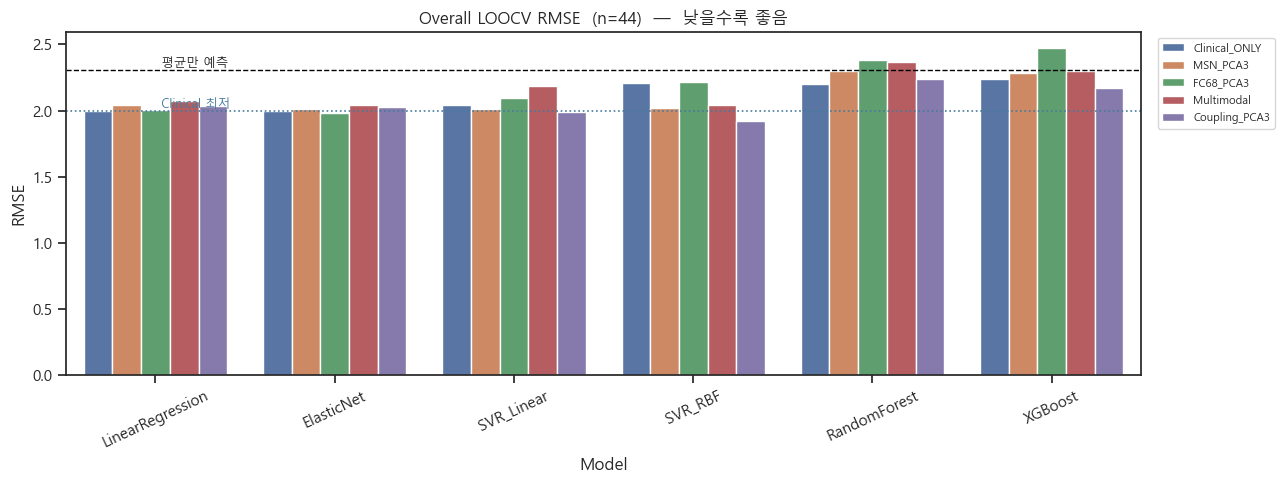

In [ ]:
# ==========================================================
# 6. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  낮을수록 좋음')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 7. 하이퍼파라미터 안정성
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost] 고유 4개, 최빈 86%
[MSN_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[MSN_PCA3 / ElasticNet] 고유 6개, 최빈 86%
[MSN_PCA3 / SVR_Linear] 고유 5개, 최빈 30%   <-- 불안정
[MSN_PCA3 / SVR_RBF] 고유 2개, 최빈 95%
[MSN_PCA3 / RandomForest] 고유 4개, 최빈 50%
[MSN_PCA3 / XGBoost] 고유 3개, 최빈 57%
[FC68_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[FC68_PCA3 / ElasticNet] 고유 3개, 최빈 93%
[FC68_PCA3 / SVR_Linear] 고유 10개, 최빈 39%   <-- 불안정
[FC68_PCA3 / SVR_RBF] 고유 11개, 최빈 52%
[FC68_PCA3 / RandomForest] 고유 9개, 최빈 23%   <-- 불안정
[FC68_PCA3 / XGBoost] 고유 7개, 최빈 32%   <-- 불안정
[Multimodal / LinearRegression] 고유 1개, 최빈 100%
[Multimodal / ElasticNet] 고유 7개, 최빈 73%
[Multimodal / SVR_Linear] 고유 11개, 최빈 45%   <-- 불안정
[Multimodal / SVR_RBF] 고유 6개, 최빈 70%
[Multimodal / RandomForest] 고유 7개, 최빈 36% 

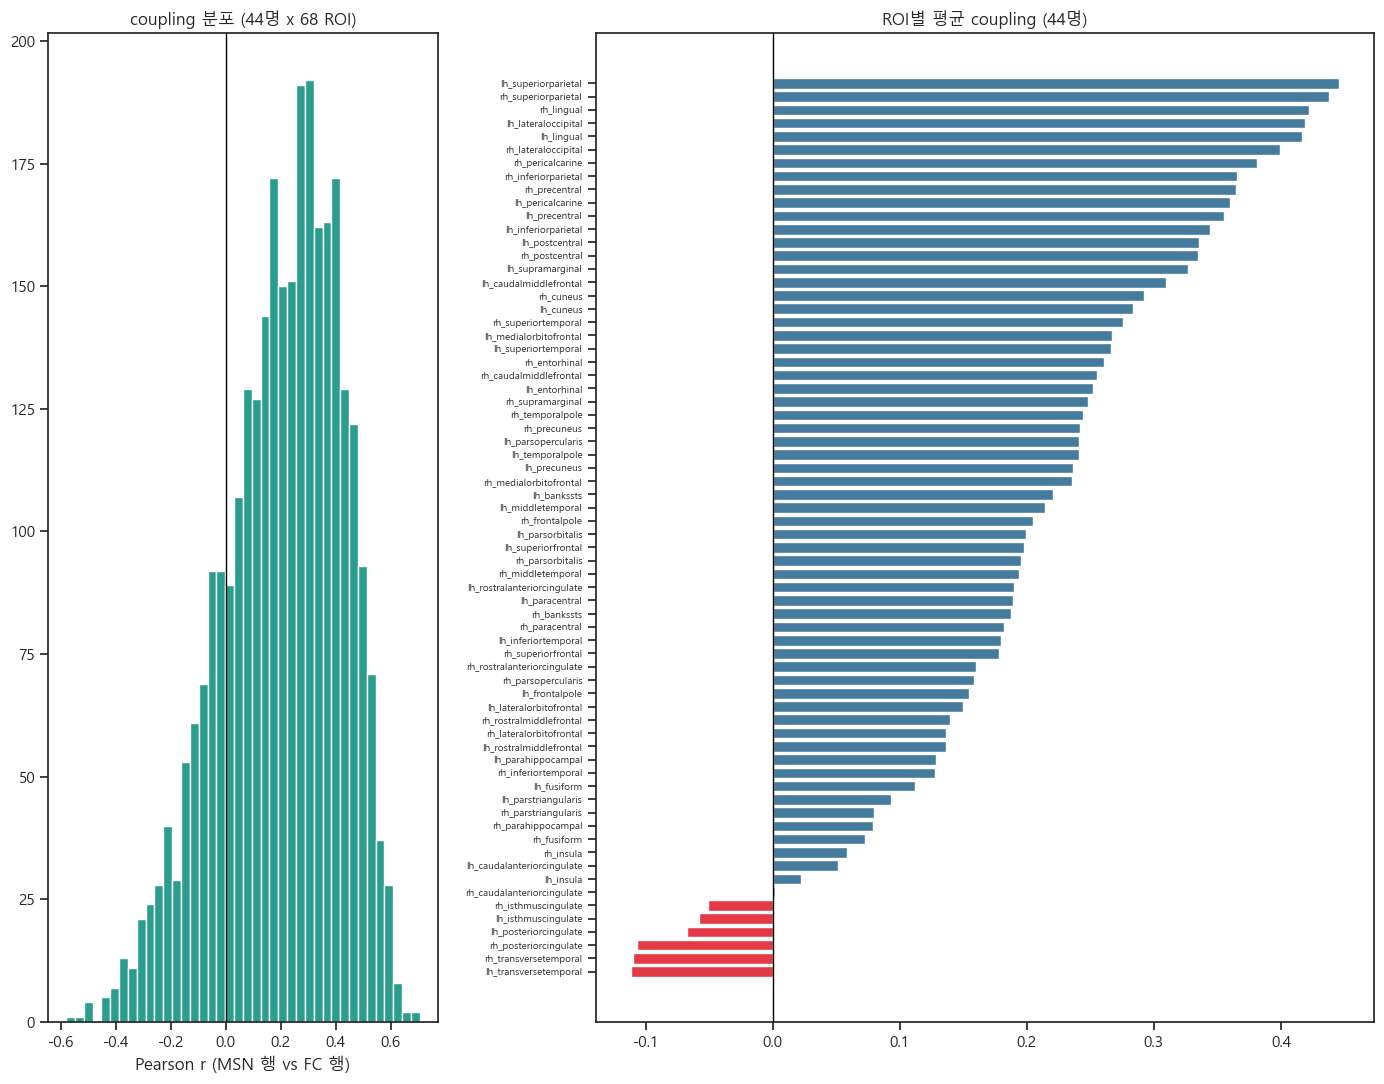

상위 5:
lh_superiorparietal    0.445
rh_superiorparietal    0.438
rh_lingual             0.422
lh_lateraloccipital    0.419
lh_lingual             0.417

하위 5:
lh_transversetemporal   -0.112
rh_transversetemporal   -0.110
rh_posteriorcingulate   -0.107
lh_posteriorcingulate   -0.067
lh_isthmuscingulate     -0.058


In [9]:
# ==========================================================
# 8. Coupling 기술통계 (sanity check — 예측과 무관, vas를 쓰지 않음)
#    선행연구: 감각·시각 피질은 coupling이 높고 연합 피질(DMN 등)은 낮다.
# ==========================================================
cp = pd.DataFrame(X_coup, columns=ROIS)
roi_mean = cp.mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 11), gridspec_kw={'width_ratios': [1, 2]})
axes[0].hist(X_coup.ravel(), bins=40, color='#2A9D8F', edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('coupling 분포 (44명 x 68 ROI)')
axes[0].set_xlabel('Pearson r (MSN 행 vs FC 행)')

colors = ['#E63946' if v < 0 else '#457B9D' for v in roi_mean.values]
axes[1].barh(roi_mean.index, roi_mean.values, color=colors)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('ROI별 평균 coupling (44명)')
axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

print('상위 5:'); print(roi_mean.tail(5)[::-1].round(3).to_string())
print('\n하위 5:'); print(roi_mean.head(5).round(3).to_string())

## 결과 읽는 법

1. **매칭된 결합이 이득인가**: `Multimodal`이 `MSN_PCA3`와 `FC68_PCA3` **둘 다**보다 낮아야 한다
   (`d_Multi_vs_MSN`, `d_Multi_vs_FC68` 둘 다 +). 한쪽만 이기면 그 모달리티 하나가 캐리한 것이다.
2. **coupling이 정보를 더하는가**: `d_Coup_vs_Clin`이 +. coupling은 매칭이 있어야만 계산되는 피처라
   이 비교가 "68×68로 맞춘 것의 가치"를 가장 직접적으로 보여준다.
3. **부호 일관성**: 6개 모델 중 몇 개가 +인지. 선형·커널(LR, EN, SVR)에서 일관 → 신뢰도 ↑,
   트리(RF, XGB)만 + → 노이즈 가능성.
4. **기준선**: `Clinical_ONLY`, 평균 예측 RMSE와 비교. 비교는 이 노트북 안에서만 한다
   (기존 morph 단독은 n=45, 기존 FC는 84 ROI라 다른 조건이다).
5. **하지 말 것**: 8번 셀에서 coupling이 튀는 ROI를 골라 피처로 쓰는 것. 같은 44명으로 고르면 leakage다.
   PCA 성분 수를 바꿔가며 돌리는 것도 같은 문제다.
